In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [21]:
def extract_regions(df, suffix):
    return sorted([col.replace(suffix, "") 
                   for col in df.columns if col.endswith(suffix)])

In [22]:
def convert_long(df, mode,name):
    suffix = f"_{mode}_{name}"
    value_cols = [c for c in df.columns if c.endswith(suffix)]
    
    df_long = df.melt(
        id_vars="year",
        value_vars=value_cols,
        var_name="region_full",
        value_name=mode
    )
    df_long["17region"] = df_long["region_full"].str.replace(suffix, "", regex=False)
    df_long = df_long.drop(columns=["region_full"])
    return df_long

In [23]:
def main(name):
    df_basin  = pd.read_csv(f"../../CSV/moran/basin_{name}_moran_3f.csv")
    df_region = pd.read_csv(f"../../CSV/moran/region_{name}_moran_3f.csv")
    regions = extract_regions(df_basin, f"_basin_{name}")
    df_basin_long  = convert_long(df_basin, mode="basin",name=name)
    df_region_long = convert_long(df_region, mode="region",name=name)

    df_merged = pd.merge(df_basin_long, df_region_long,
                        on=["year", "17region"], how="inner")

    n = len(regions)
    ncols = 5
    nrows = int(np.ceil(n / ncols))

    fig, axes = plt.subplots(nrows, ncols, figsize=(16, 12), sharex=True)
    axes = axes.flatten()

    for i, reg in enumerate(regions):
        ax = axes[i]

        d = df_merged[df_merged["17region"] == reg]

        ax.plot(d["year"], d["basin"],  color="blue", label="Basin")
        ax.plot(d["year"], d["region"], color="red",  label="Region")

        ax.set_title(reg)
        ax.set_ylim(0, 1)
        ax.grid(alpha=0.3)

    handles, labels = ax.get_legend_handles_labels()
    fig.legend(handles, labels, loc="lower right", ncol=2,fontsize=22)

    for j in range(i+1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout(rect=[0, 0.05, 1, 1]) 
    plt.savefig(f"../../plot/moran/17regions_{name}_moran.png", dpi=600, bbox_inches="tight")
    plt.show()


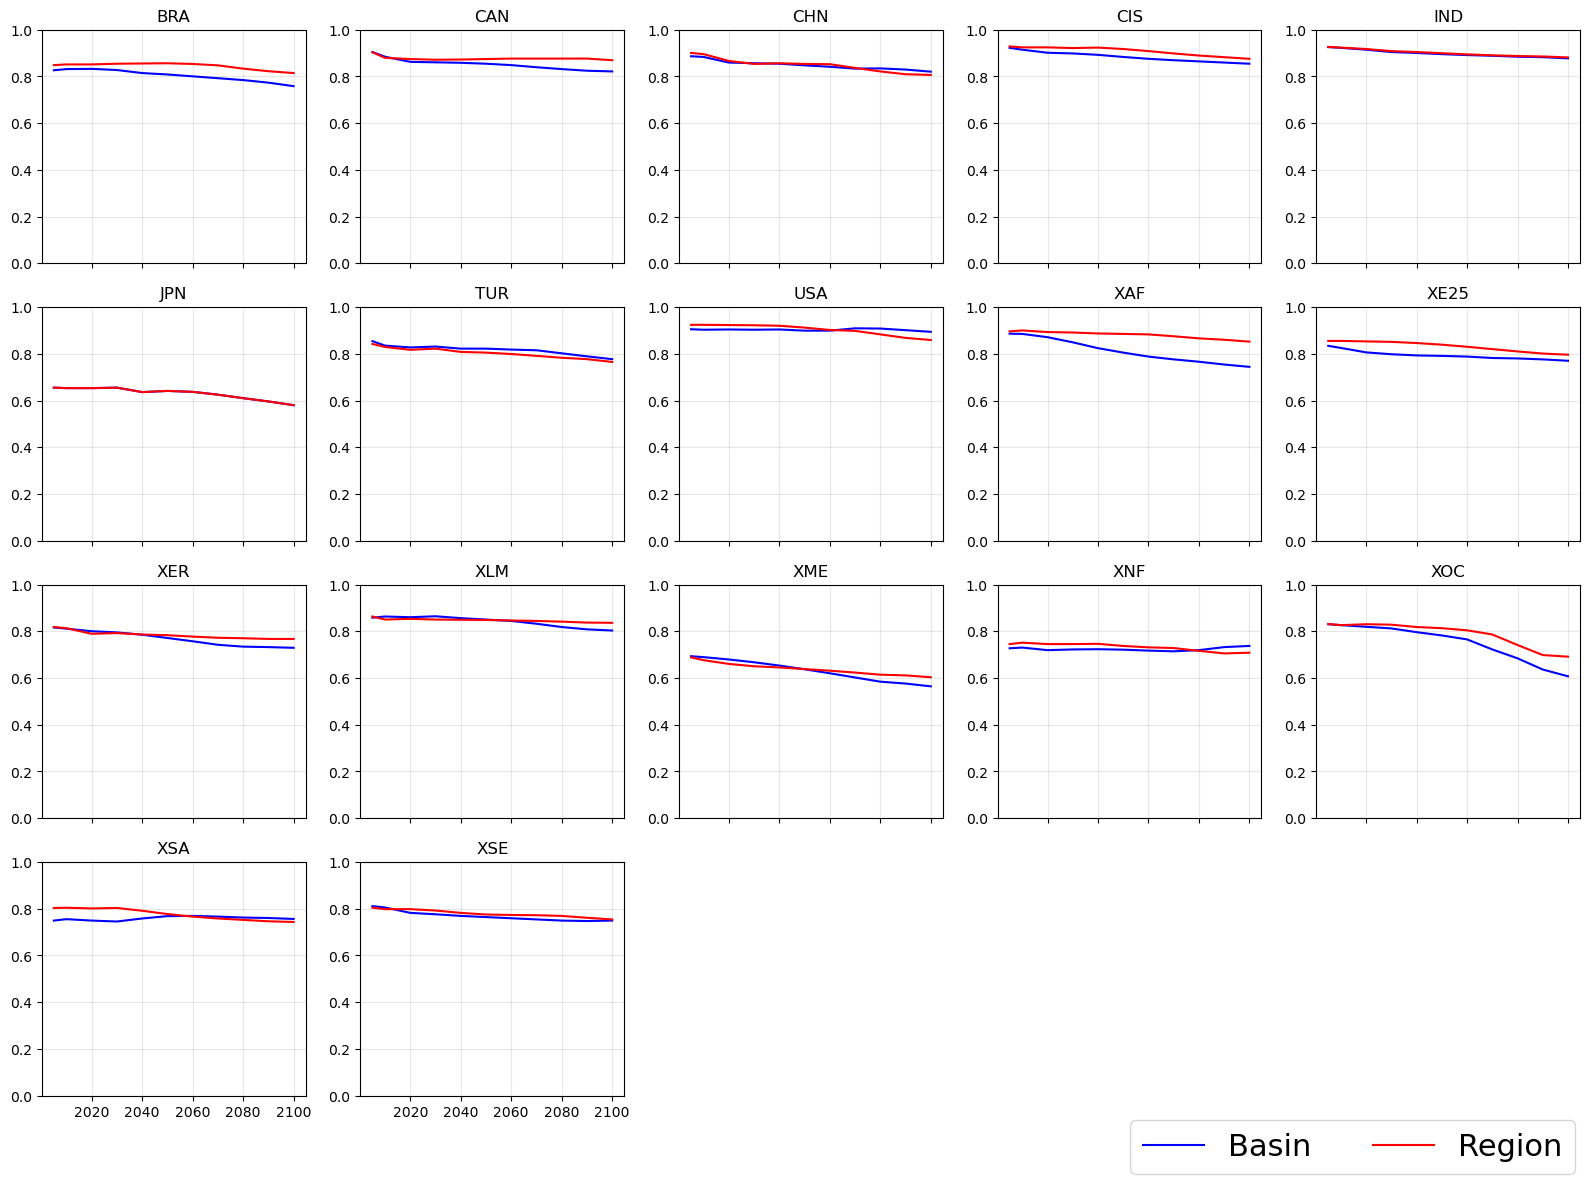

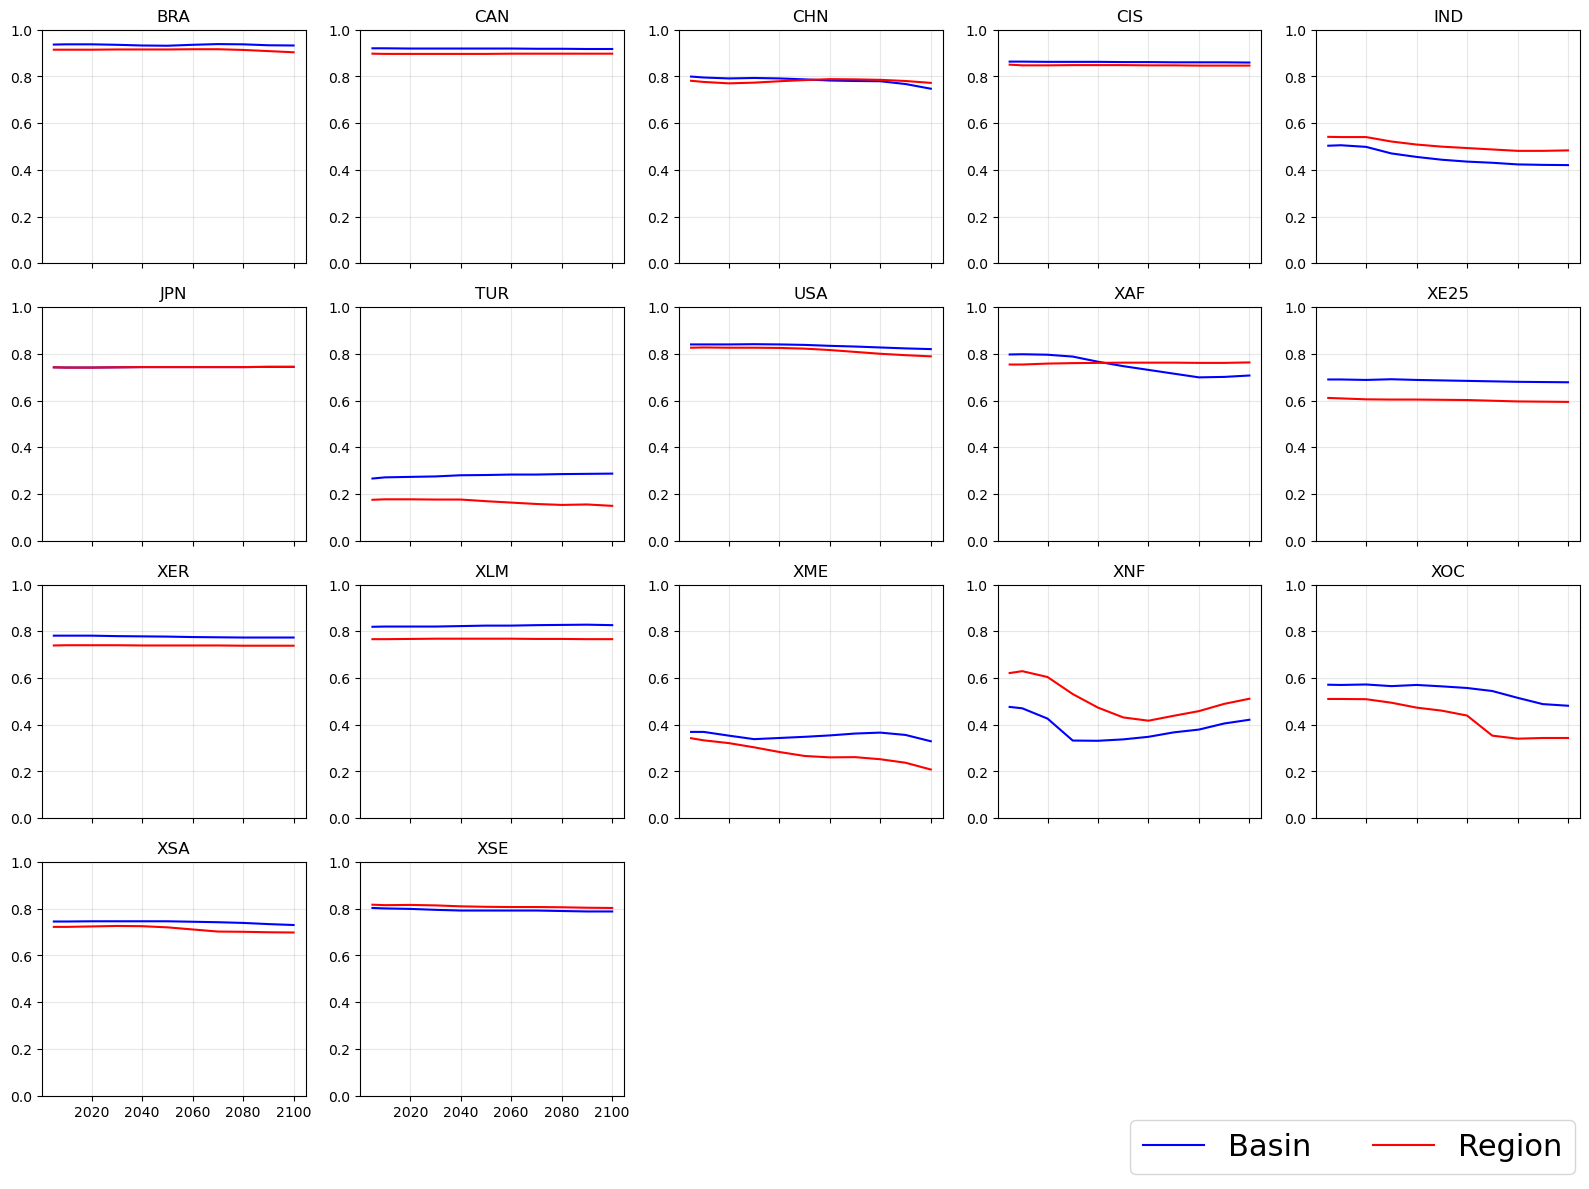

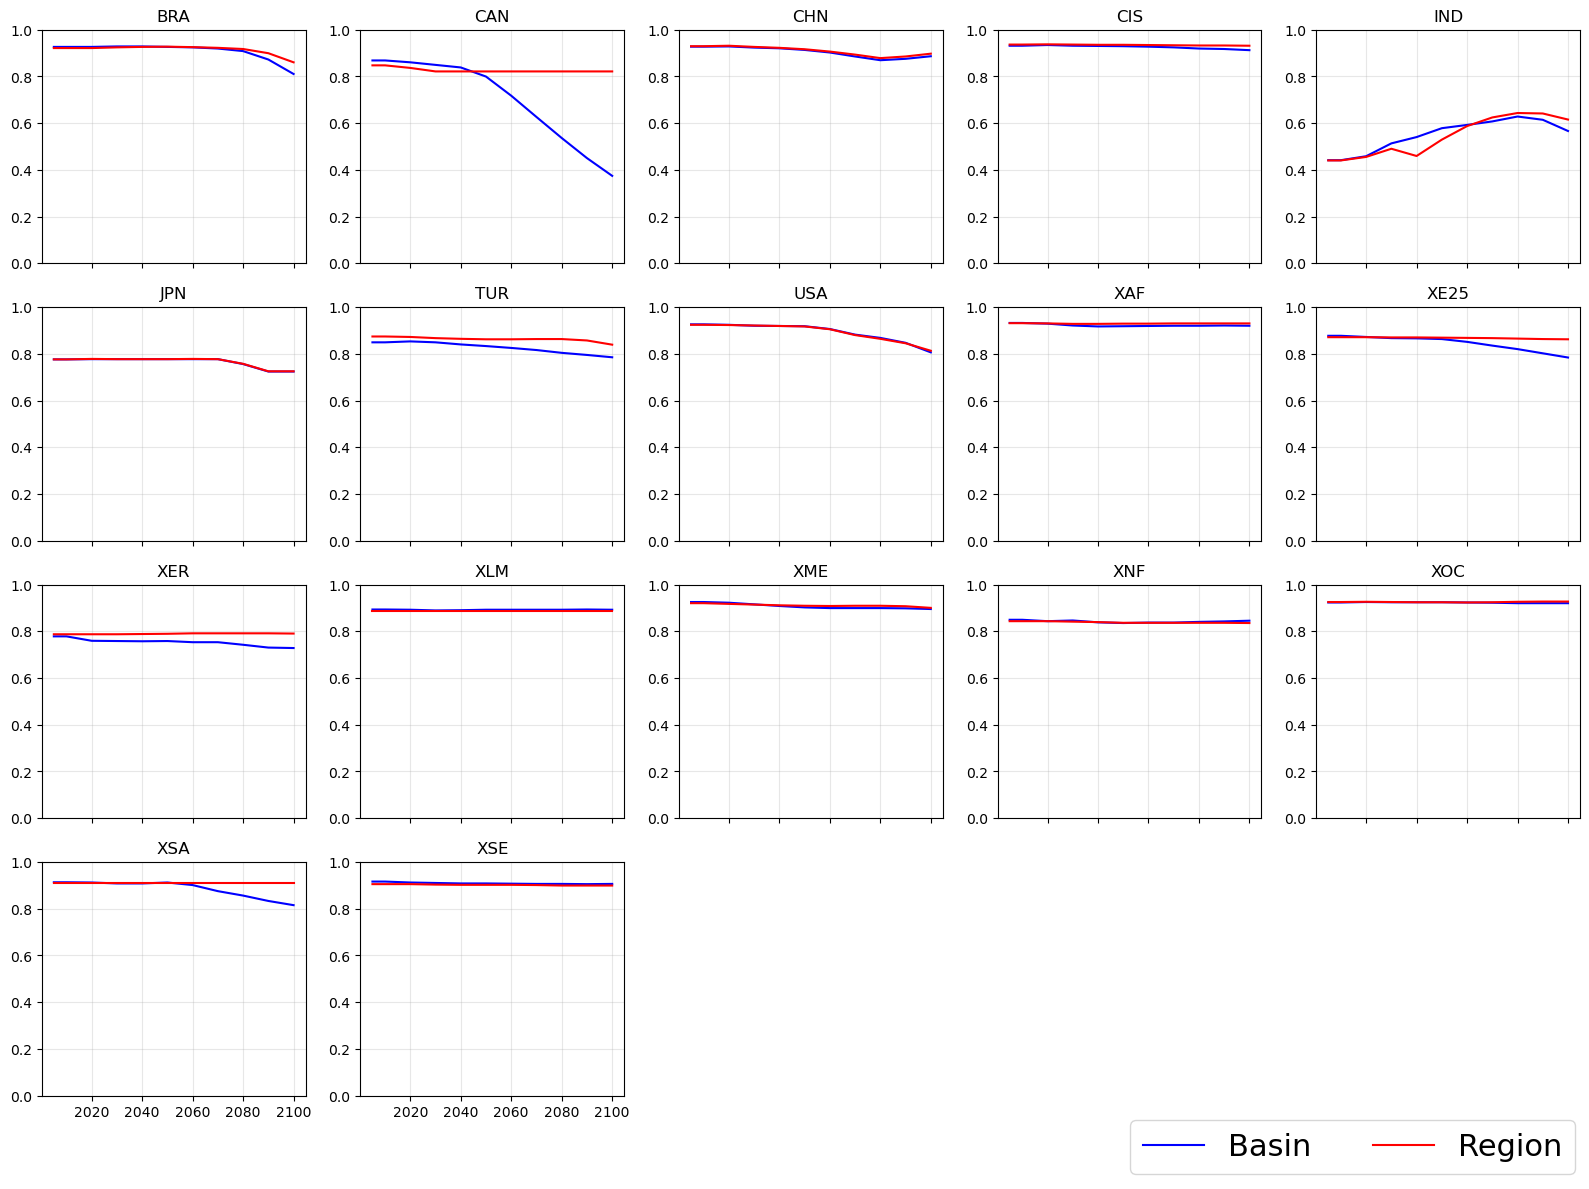

In [24]:
names=["agri","forest","grassland"]
for name in names:
    main(name)